In [1]:
import pandas as pd

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [2]:
# Convert to datetime
df["Month"] = pd.to_datetime(df["Month"])

# Set as index
df.set_index("Month", inplace=True)

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


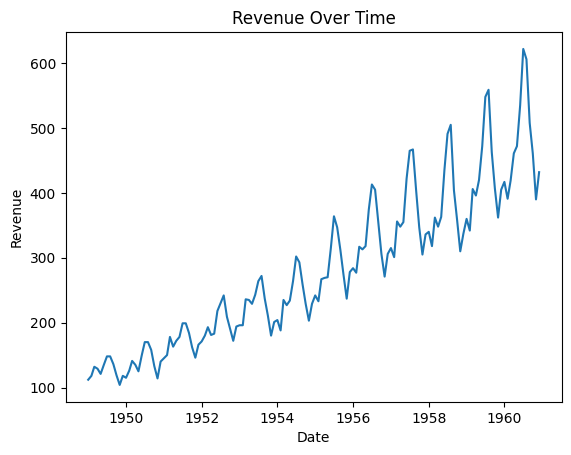

In [3]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df)
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

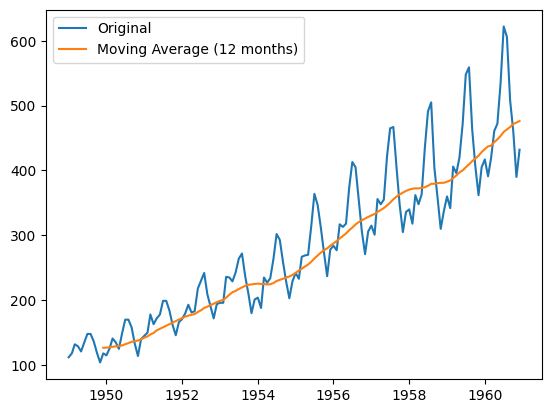

In [4]:
df["MA_12"] = df["Passengers"].rolling(window=12).mean()

plt.figure()
plt.plot(df["Passengers"], label="Original")
plt.plot(df["MA_12"], label="Moving Average (12 months)")
plt.legend()
plt.show()

In [5]:
train = df.iloc[:120]
test = df.iloc[120:]

In [6]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train["Passengers"], order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


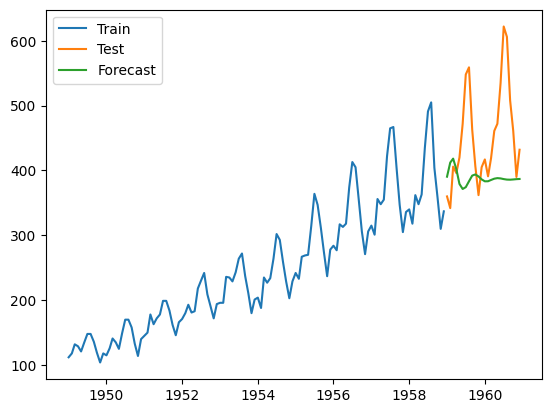

In [7]:
plt.figure()
plt.plot(train["Passengers"], label="Train")
plt.plot(test["Passengers"], label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.show()

In [8]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test["Passengers"], forecast))
print("RMSE:", rmse)

RMSE: 101.65923233503167


## Key Observations

* The data shows a steady upward trend over time, indicating consistent growth
* There are clear repeating peaks, suggesting strong seasonal patterns
* The forecast follows the overall trend but slightly underestimates peak values

## Insights

* The upward trend suggests increasing demand and potential for continued business growth
* Seasonal patterns indicate predictable high-demand periods, which can be used for better planning and resource allocation
* While the model captures long-term trends, improving seasonal modeling could increase forecast accuracy

## Summary

This analysis shows that revenue is not only growing but also follows predictable seasonal behavior. By leveraging these patterns, businesses can make better decisions around planning, forecasting, and resource management.
